Executando 100 simulações...
Simulações concluídas. Gerando histogramas...


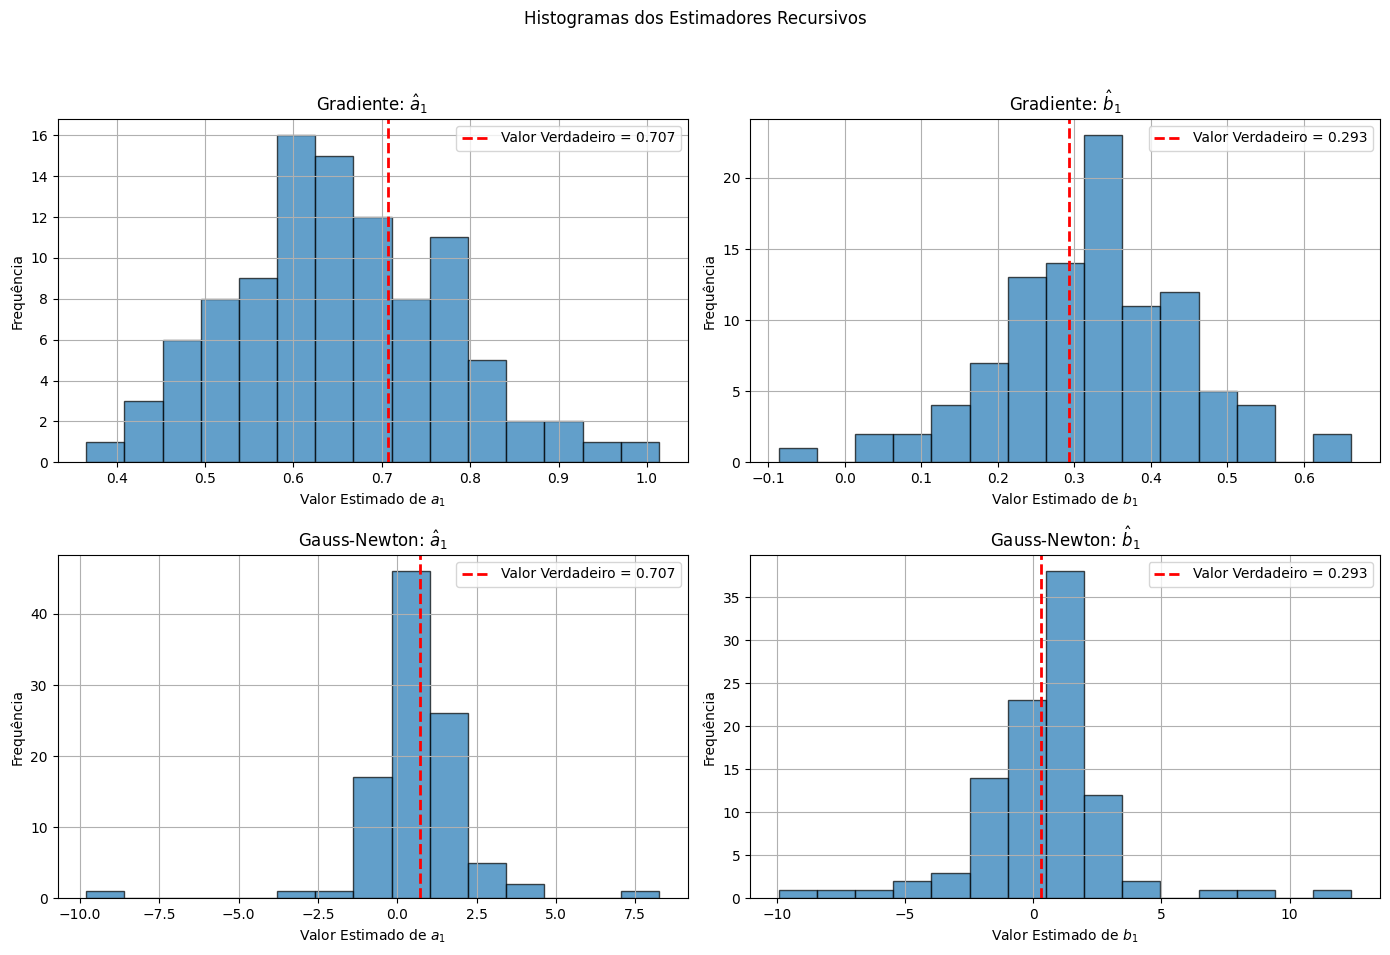

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# System and Simulation Configuration
# --------------------------------------------------------------------------

# True system parameters
a1_true = 0.707
b1_true = 0.293
theta_true = np.array([a1_true, b1_true])

# Noise covariance
noise_variance = 3.0

# Simulation parameters
N = 1000  # Number of data samples
num_realizations = 100  # Number of different noise realizations 

# --------------------------------------------------------------------------
# Function to Simulate the ARX System
# --------------------------------------------------------------------------
def simulate_arx_system(N, theta, noise_var):
    """
    Simulates the ARX system y(k) = a1*y(k-1) + b1*u(k-1) + eta(k).
    
    Args:
        N (int): Number of samples.
        theta (np.array): True parameter vector [a1, b1].
        noise_var (float): Variance of the white noise eta(k).

    Returns:
        tuple: (u, y) input and output signals.
    """
    a1, b1 = theta[0], theta[1]
    
    # Generate a persistently exciting input signal (white noise)
    u = np.random.randn(N)
    
    # Generate white noise with specified variance 
    eta = np.sqrt(noise_var) * np.random.randn(N)
    
    # Initialize output vector
    y = np.zeros(N)
    
    # Simulate the system dynamics
    for k in range(1, N):
        y[k] = a1 * y[k-1] + b1 * u[k-1] + eta[k]
        
    return u, y

# --------------------------------------------------------------------------
# Recursive Estimator Implementations
# --------------------------------------------------------------------------
def estimate_gradient_like(y, u, K_bar):
    """
    Estimates parameters using the gradient-like recursive estimator.
    Update rule: theta_k = theta_{k-1} + K_bar * psi_k * error_k
    
    Args:
        y (np.array): Output signal.
        u (np.array): Input signal.
        K_bar (float): Fixed gain factor.

    Returns:
        np.array: Final estimated parameter vector.
    """
    # Initial parameter estimates
    theta_est = np.zeros(2)
    N = len(y)
    
    for k in range(1, N):
        # Form the regressor vector Psi_k = [y(k-1), u(k-1)]^T
        psi = np.array([y[k-1], u[k-1]])
        
        # Prediction error
        error = y[k] - psi.T @ theta_est
        
        # Gain vector K_k = K_bar * Psi_k 
        Kk = K_bar * psi
        
        # Update parameter estimates
        theta_est = theta_est + Kk * error
        
    return theta_est

def estimate_gauss_newton_like(y, u):
    """
    Estimates parameters using the Gauss-Newton-like recursive estimator.
    Update rule: theta_k = theta_{k-1} + (psi_k^T * psi_k)^-1 * psi_k * error_k 
    
    Args:
        y (np.array): Output signal.
        u (np.array): Input signal.

    Returns:
        np.array: Final estimated parameter vector.
    """
    # Initial parameter estimates
    theta_est = np.zeros(2)
    N = len(y)
    
    for k in range(1, N):
        # Form the regressor vector Psi_k = [y(k-1), u(k-1)]^T
        psi = np.array([y[k-1], u[k-1]])
        
        # Calculate psi.T * psi, add epsilon for numerical stability
        psi_norm_sq = psi.T @ psi
        if psi_norm_sq < 1e-9:
            continue

        # Prediction error
        error = y[k] - psi.T @ theta_est
        
        # Gain vector K_k = (Psi_k^T * Psi_k)^-1 * Psi_k 
        Kk = (1 / psi_norm_sq) * psi
        
        # Update parameter estimates
        theta_est = theta_est + Kk * error
        
    return theta_est

# --------------------------------------------------------------------------
# Main Execution Block
# --------------------------------------------------------------------------
# Store final estimates from all realizations
grad_estimates = np.zeros((num_realizations, 2))
gn_estimates = np.zeros((num_realizations, 2))

# A fixed K that does not lead to a very large covariance
# This choice may require tuning. A small value is generally safer.
K_bar_fixed = 0.01

print(f"Executando {num_realizations} simulações...")

for i in range(num_realizations):
    # Simulate the system for a new noise realization
    u, y = simulate_arx_system(N, theta_true, noise_variance)
    
    # a) Estimate parameters with both methods 
    grad_estimates[i, :] = estimate_gradient_like(y, u, K_bar_fixed)
    gn_estimates[i, :] = estimate_gauss_newton_like(y, u)

print("Simulações concluídas. Gerando histogramas...")

# --- Combined Histogram Figure for All Estimators ---
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Histogramas dos Estimadores Recursivos')

# Top row: Gradient-like estimator
axs[0, 0].hist(grad_estimates[:, 0], bins=15, edgecolor='black', alpha=0.7)
axs[0, 0].axvline(a1_true, color='r', linestyle='--', linewidth=2, label=f'Valor Verdadeiro = {a1_true}')
axs[0, 0].axvline(np.mean(grad_estimates[:, 0]), color='g', linestyle='-', linewidth=2, label=f'Média Estimada = {np.mean(grad_estimates[:, 0]):.4f}')
axs[0, 0].set_title('Gradiente: $\\hat{a}_1$')
axs[0, 0].set_xlabel('Valor Estimado de $a_1$')
axs[0, 0].set_ylabel('Frequência')
axs[0, 0].legend()
axs[0, 0].grid(True)

axs[0, 1].hist(grad_estimates[:, 1], bins=15, edgecolor='black', alpha=0.7)
axs[0, 1].axvline(b1_true, color='r', linestyle='--', linewidth=2, label=f'Valor Verdadeiro = {b1_true}')
axs[0, 1].axvline(np.mean(grad_estimates[:, 1]), color='g', linestyle='-', linewidth=2, label=f'Média Estimada = {np.mean(grad_estimates[:, 1]):.4f}')
axs[0, 1].set_title('Gradiente: $\\hat{b}_1$')
axs[0, 1].set_xlabel('Valor Estimado de $b_1$')
axs[0, 1].set_ylabel('Frequência')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Bottom row: Gauss-Newton-like estimator
axs[1, 0].hist(gn_estimates[:, 0], bins=15, edgecolor='black', alpha=0.7)
axs[1, 0].axvline(a1_true, color='r', linestyle='--', linewidth=2, label=f'Valor Verdadeiro = {a1_true}')
axs[1, 0].axvline(np.mean(gn_estimates[:, 0]), color='g', linestyle='-', linewidth=2, label=f'Média Estimada = {np.mean(gn_estimates[:, 0]):.4f}')
axs[1, 0].set_title('Gauss-Newton: $\\hat{a}_1$')
axs[1, 0].set_xlabel('Valor Estimado de $a_1$')
axs[1, 0].set_ylabel('Frequência')
axs[1, 0].legend()
axs[1, 0].grid(True)

axs[1, 1].hist(gn_estimates[:, 1], bins=15, edgecolor='black', alpha=0.7)
axs[1, 1].axvline(b1_true, color='r', linestyle='--', linewidth=2, label=f'Valor Verdadeiro = {b1_true}')
axs[1, 1].axvline(np.mean(gn_estimates[:, 1]), color='g', linestyle='-', linewidth=2, label=f'Média Estimada = {np.mean(gn_estimates[:, 1]):.4f}')
axs[1, 1].set_title('Gauss-Newton: $\\hat{b}_1$')
axs[1, 1].set_xlabel('Valor Estimado de $b_1$')
axs[1, 1].set_ylabel('Frequência')
axs[1, 1].legend()
axs[1, 1].grid(True)

fig.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.savefig('entrega/imagens/histograma_1a.png')
